In [6]:
import pandas as pd
import numpy as np

# Define number of records
num_customers = 500

# Create synthetic data
data = {
    "Customer_ID": [f"C{str(i).zfill(3)}" for i in range(1, num_customers+1)],
    "Age": np.random.randint(18, 60, num_customers),
    "Gender": np.random.choice(["Male", "Female", "Other"], num_customers),
    "Income": np.random.randint(30000, 100000, num_customers),
    "Spending_Score": np.random.randint(1, 100, num_customers),
    "Purchase_Frequency": np.random.randint(1, 20, num_customers),
    "Product_Category": np.random.choice(["Electronics", "Apparel", "Grocery", "Beauty", "Home Decor"], num_customers),
    "Total_Spending": np.random.randint(1000, 10000, num_customers),
    "Preferred_Payment_Method": np.random.choice(["Credit Card", "UPI", "Cash", "Wallet"], num_customers)
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("customer_segmentation_data.csv", index=False)

print("Dataset created successfully!")


Dataset created successfully!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_csv("customer_segmentation_data.csv")
df.head()  # Display the first few rows

,Customer_ID,Age,Gender,Income,Spending_Score,Purchase_Frequency,Product_Category,Total_Spending,Preferred_Payment_Method
0,C001,40,Other,67532,47,3,Grocery,9576,UPI
1,C002,58,Other,64822,39,2,Grocery,2959,Credit Card
2,C003,28,Other,54153,64,15,Home Decor,3987,Credit Card
3,C004,59,Male,87054,91,16,Beauty,6583,Wallet
4,C005,53,Female,81166,35,7,Apparel,1483,Cash


In [10]:
df.dropna(inplace=True)  # Handle missing values
df.rename(columns={'Total_Spending': 'Spending'}, inplace=True)  # Rename for clarity

In [12]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['Income', 'Spending', 'Purchase_Frequency']])

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Visualization

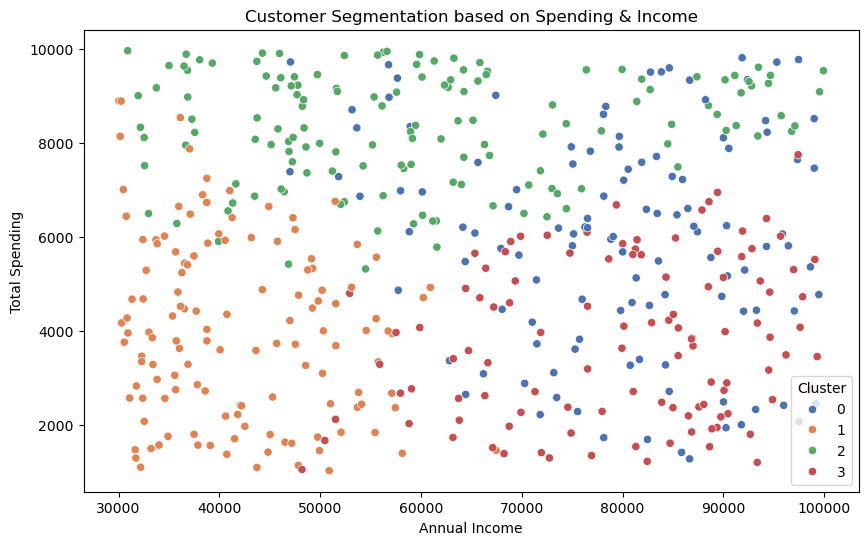

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Income'], y=df['Spending'], hue=df['Cluster'], palette="deep")
plt.title("Customer Segmentation based on Spending & Income")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.show()

# 1. Customer Segmentation Distribution

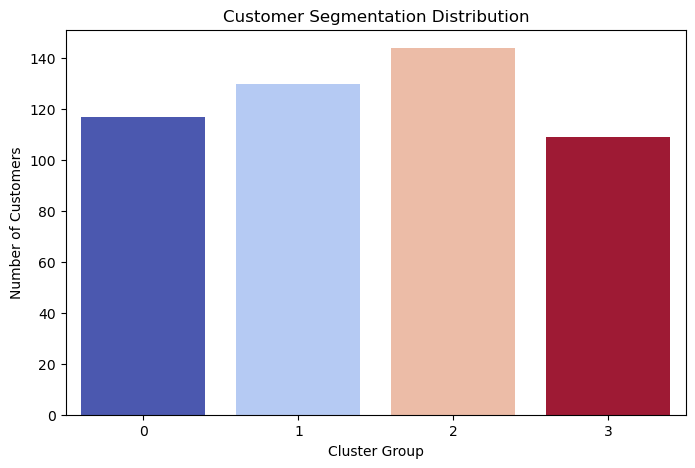

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x=df['Cluster'], hue=df['Cluster'], palette='coolwarm', legend=False)
plt.title("Customer Segmentation Distribution")
plt.xlabel("Cluster Group")
plt.ylabel("Number of Customers")
plt.show()

# 2. Spending Pattern vs. Income

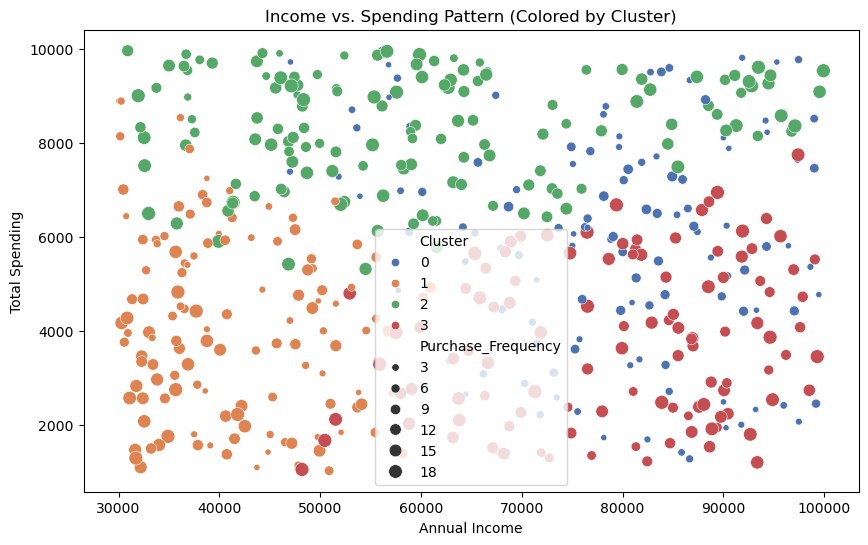

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Income'], y=df['Spending'], hue=df['Cluster'], palette="deep", size=df['Purchase_Frequency'], sizes=(20, 100))
plt.title("Income vs. Spending Pattern (Colored by Cluster)")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.show()

# 3. Preferred Payment Methods Across Clusters

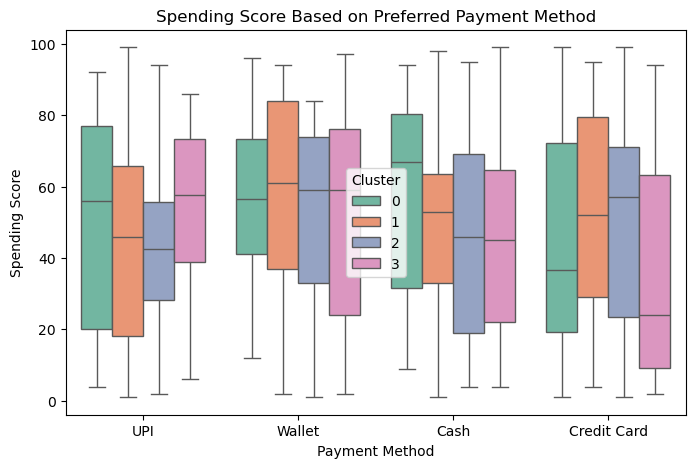

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Preferred_Payment_Method'], y=df['Spending_Score'], hue=df['Cluster'], palette="Set2")
plt.title("Spending Score Based on Preferred Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Spending Score")
plt.show()

# 4. Customer Engagement Analysis

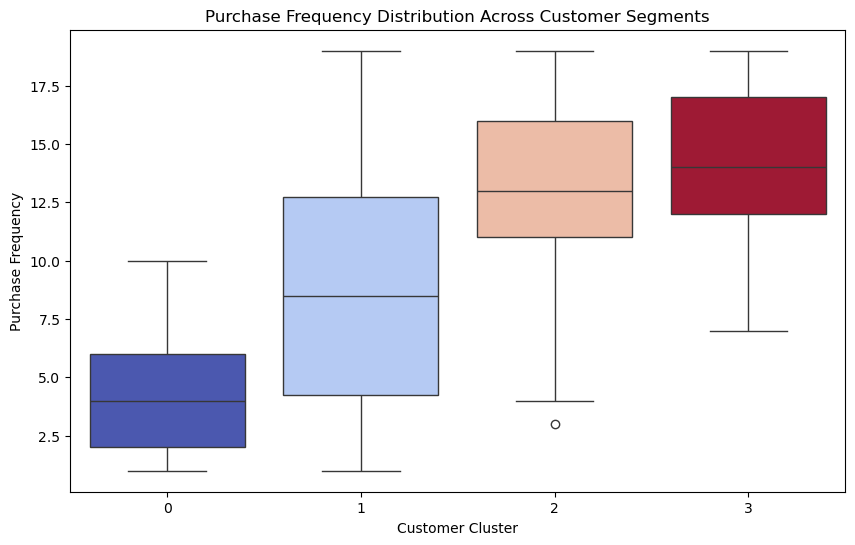

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Cluster'], y=df['Purchase_Frequency'], hue=df['Cluster'], palette="coolwarm", legend=False)
plt.title("Purchase Frequency Distribution Across Customer Segments")
plt.xlabel("Customer Cluster")
plt.ylabel("Purchase Frequency")
plt.show()